# Euclid Q1: an independent oxygen-doublet measurement

Measure the energy-flux ratio of [O III] 5007/4959 and compare it with **2.98**.
We fit the actual SIR signal, not an SPE template. Both line fluxes, centres and
widths are independent. This is a selected-object demonstration, not a population
study or a precision test of fundamental constants.

Run top to bottom from the project directory. Dependencies: numpy, pandas, scipy,
matplotlib, astropy, astroquery, requests and ipykernel. If needed, install these
with `%pip install` in this kernel, then restart it. Astroquery must provide IRSA's
`query_ssa` and `query_sia` methods.

Small public spectra and metadata are cached in `data_work/euclid04`. PNGs go to
`photo`. No complete catalogue or full image mosaic is downloaded. Existing
notebooks and their data are not changed.

In [1]:
# USER INPUT - TARGETS
# Fixed shortlist, from a good-flag, high-S/N Q1 oxygen-line query.
# Select the FIRST suitable target, never the ratio nearest the prediction.
#candidate_object_ids = [2664981964636037831,-594112133505859105, -588973508506640061]
candidate_object_ids = [-542037042283144703, -629328037490673904, 2752357571659156082 ]
allow_fallback_search = True
search_redshift_range = (1.55, 1.75)
search_limit = 12
minimum_catalogue_probability = 0.99
minimum_catalogue_oxygen_snr = 20.0

# USER INPUT - MEASUREMENT (exploratory quality cuts, not official Euclid cuts)
fit_margin_nm = 15.0
min_dithers = 3
reject_mask_bits = 1 | 64  # NOT_USE and unreliable absolute flux calibration
minimum_line_snr = 5.0
maximum_reduced_chi2 = 3.0
maximum_missing_core_fraction = 0.25
center_tolerance_nm = 3.0
sigma_bounds_nm = (0.4, 4.0)
integration_half_width_nm = 4.0
continuum_exclusion_nm = 5.0
monte_carlo_draws = 1000
random_seed = 20260926

# USER INPUT - OUTPUT
retrieve_image = True
cutout_size_arcsec = 12.0
export_png = True
figure_dpi = 300
refresh_catalogues = False
cache_directory = 'data_work/euclid04'
photo_directory = 'photo'

## 1. Catalogue selection and provenance

Use ESA PDR TAP (`https://eas.esac.esa.int/tap-server/tap`), schema `catalogue`.
Join on `object_id`, and additionally on `spe_rank` for line measurements.
Require rank 0, galaxy classification, high redshift probability, zero overall and
galaxy hard errors, positive oxygen flux, high S/N, and line quality **212**
(good Gaussian-fit measurement in the red grism). Other warning flags are shown.
These catalogue criteria only shortlist targets. The actual SIR pixels determine
suitability. If none passes, a bounded remote search uses the same criteria.

In [2]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import warnings
import importlib.metadata
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table, QTable
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from astroquery.esa.euclid import Euclid
from astroquery.ipac.irsa import Irsa
from scipy.optimize import least_squares
from scipy.special import ndtr
from IPython.display import display, Markdown

cache, photos = Path(cache_directory), Path(photo_directory)
cache.mkdir(parents=True, exist_ok=True)
photos.mkdir(parents=True, exist_ok=True)
assert Euclid.environment == 'PDR', 'Use the public Euclid environment.'
assert 0 < sigma_bounds_nm[0] < sigma_bounds_nm[1]
assert fit_margin_nm > continuum_exclusion_nm > integration_half_width_nm > 0
assert 100 <= monte_carlo_draws and 0 < search_limit <= 100
assert 0 < cutout_size_arcsec <= 60

# Traditional labels 4959/5007 are rounded air wavelengths in Angstroms.
# The actual analysis uses vacuum wavelengths, in nm.
REST_NM = np.array([496.0295, 500.8240])
FLUX_UNIT = u.erg / u.s / u.cm**2
DENSITY_UNIT = FLUX_UNIT / u.nm
FLUX_SCALE = 1e-16
THEORY_RATIO = 2.98  # Comparison only; NEVER passed to the fitter/selector.

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def query_table(query, label):
    key = hashlib.sha256(query.encode()).hexdigest()[:16]
    path = cache / f'{label}_{key}.ecsv'
    if path.exists() and not refresh_catalogues:
        record = json.loads(path.with_suffix('.json').read_text())
        assert sha256(path) == record['sha256'], 'Catalogue cache checksum mismatch.'
        return Table.read(path)
    job = Euclid.launch_job_async(query, output_format='votable', dump_to_file=False)
    table = job.get_results()
    table.write(path, format='ascii.ecsv', overwrite=True)
    path.with_suffix('.json').write_text(json.dumps({
        'query': query, 'job_id': job.jobid, 'release': 'Euclid Q1',
        'utc': datetime.now(timezone.utc).isoformat(), 'sha256': sha256(path)
    }, indent=2))
    return table

source_select = '''
SELECT {top} g.object_id, g.spe_z, g.spe_z_err, g.spe_z_prob, g.spe_z_rel,
g.spe_subclass, c.spe_class, c.spe_gal_prob,
m.right_ascension, m.declination, m.flux_h_2fwhm_aper,
q.spe_error_flag, q.spe_gal_error_flag, q.spe_warning_flag,
q.spe_gal_warning_flag, q.spe_class_warning_flag,
l.spe_line_flux_gf AS oiii_catalogue_flux,
l.spe_line_snr_gf AS oiii_catalogue_snr,
l.spe_line_qual_gf AS oiii_catalogue_quality
FROM catalogue.spectro_zcatalog_spe_galaxy_candidates AS g
JOIN catalogue.spectro_zcatalog_spe_classification AS c ON g.object_id=c.object_id
JOIN catalogue.mer_catalogue AS m ON g.object_id=m.object_id
JOIN catalogue.spectro_zcatalog_spe_quality AS q ON g.object_id=q.object_id
JOIN catalogue.spectro_line_features_catalog_spe_line_features_cat AS l
  ON g.object_id=l.object_id AND g.spe_rank=l.spe_rank
WHERE g.spe_rank=0 AND LOWER(c.spe_class)='galaxy'
AND l.spe_line_name='OIII5008'
'''
quality_where = f'''
AND g.spe_z_prob >= {minimum_catalogue_probability}
AND q.spe_error_flag=0 AND q.spe_gal_error_flag=0
AND l.spe_line_snr_gf >= {minimum_catalogue_oxygen_snr}
AND l.spe_line_flux_gf>0 AND l.spe_line_qual_gf=212
'''
ids_sql = ','.join(str(int(x)) for x in candidate_object_ids)
candidate_query = source_select.format(top='') + quality_where + f'AND g.object_id IN ({ids_sql})'
sources = query_table(candidate_query, 'source_details')
assert len(set(sources['object_id'])) == len(sources), 'Ambiguous catalogue join.'
display(sources.to_pandas())
print(candidate_query)
print('Versions:', {p: importlib.metadata.version(p) for p in
                   ['numpy', 'scipy', 'astropy', 'astroquery', 'matplotlib']})

,object_id,spe_z,spe_z_err,spe_z_prob,spe_z_rel,spe_subclass,spe_class,spe_gal_prob,right_ascension,declination,flux_h_2fwhm_aper,spe_error_flag,spe_gal_error_flag,spe_warning_flag,spe_gal_warning_flag,spe_class_warning_flag,oiii_catalogue_flux,oiii_catalogue_snr,oiii_catalogue_quality
0,2752357571659156082,1.558830,0.000114,0.999999,0.997010,Lya_abs_SB3,galaxy,1.0,275.235757,65.915608,18.780029,0,0,2,0,0,1.929716e-15,71.004288,212
1,-629328037490673904,1.710818,0.000110,1.000000,0.997682,Lya_abs_SB3,galaxy,1.0,62.932804,-49.067390,8.996327,0,0,2,0,0,2.630602e-15,86.325165,212
2,-542037042283144703,1.617057,0.000126,0.999987,0.997476,Lya_abs_SB3,galaxy,1.0,54.203704,-28.314470,8.298696,0,0,2,0,0,3.369231e-15,76.600113,212



SELECT  g.object_id, g.spe_z, g.spe_z_err, g.spe_z_prob, g.spe_z_rel,
g.spe_subclass, c.spe_class, c.spe_gal_prob,
m.right_ascension, m.declination, m.flux_h_2fwhm_aper,
q.spe_error_flag, q.spe_gal_error_flag, q.spe_warning_flag,
q.spe_gal_warning_flag, q.spe_class_warning_flag,
l.spe_line_flux_gf AS oiii_catalogue_flux,
l.spe_line_snr_gf AS oiii_catalogue_snr,
l.spe_line_qual_gf AS oiii_catalogue_quality
FROM catalogue.spectro_zcatalog_spe_galaxy_candidates AS g
JOIN catalogue.spectro_zcatalog_spe_classification AS c ON g.object_id=c.object_id
JOIN catalogue.mer_catalogue AS m ON g.object_id=m.object_id
JOIN catalogue.spectro_zcatalog_spe_quality AS q ON g.object_id=q.object_id
JOIN catalogue.spectro_line_features_catalog_spe_line_features_cat AS l
  ON g.object_id=l.object_id AND g.spe_rank=l.spe_rank
WHERE g.spe_rank=0 AND LOWER(c.spe_class)='galaxy'
AND l.spe_line_name='OIII5008'

AND g.spe_z_prob >= 0.99
AND q.spe_error_flag=0 AND q.spe_gal_error_flag=0
AND l.spe_line_snr_gf >= 2

## 2. Actual observed spectra

The official IRSA Q1 mirror supplies the same SIR product through SSA collection
`euclid_DpdSirCombinedSpectra`. A one-arcsecond search locates the product;
its embedded object ID must match exactly. ESA's product-link service was
temporarily failing during development, while its catalogue service worked.

IRSA embeds **FSCALE in the units** of SIGNAL and VAR. Astropy handles that scale
and the per-Angstrom to per-nm conversion, once only. We check `UNCERTAINTY`
against `sqrt(VAR)`. No unit guessing, smoothing, negative-flux clipping or
ratio-based rejection is used. Mask bits 1 and 64 and insufficient dithers are
excluded. A stricter MASK=0 fit is included as a sensitivity check.
SIR's LOW_SNR bit (2) concerns the fraction of contributing unmasked pixels; it
does not mean that an emission line itself has low measured flux S/N. Retaining
these bins follows the documented basic SIR/SPE mask treatment, but is a caveat.

In [3]:
def get_spectrum(source):
    oid = int(source['object_id'])
    pos = SkyCoord(float(source['right_ascension'])*u.deg, float(source['declination'])*u.deg)
    ssa_path = cache / f'ssa_{oid}.ecsv'
    data_path = cache / f'sir_{oid}.xml'
    prov_path = cache / f'sir_{oid}.provenance.json'
    if ssa_path.exists():
        ssa = Table.read(ssa_path)
    else:
        result = Irsa.query_ssa(pos=pos, radius=1*u.arcsec, collection='euclid_DpdSirCombinedSpectra')
        ssa = result.to_table() if hasattr(result, 'to_table') else result
        ssa.write(ssa_path, format='ascii.ecsv', overwrite=True)
    if len(ssa) != 1:
        raise RuntimeError(f'Expected one SSA result for {oid}, got {len(ssa)}.')
    url = str(ssa['access_url'][0])
    if not data_path.exists():
        response = requests.get(url, timeout=(20, 120))
        response.raise_for_status()
        data_path.write_bytes(response.content)
        prov_path.write_text(json.dumps({'url': url, 'sha256': sha256(data_path),
                            'utc': datetime.now(timezone.utc).isoformat()}, indent=2))
    provenance = json.loads(prov_path.read_text())
    assert sha256(data_path) == provenance['sha256'], 'Spectrum checksum mismatch.'
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=u.UnitsWarning, message='.*deprecated.*')
        table = QTable.read(data_path, format='votable')
    assert table.meta.get('ID') == f'Euclid_{oid}_Combined', 'Wrong spectrum object ID.'
    required = {'WAVELENGTH', 'SIGNAL', 'VAR', 'MASK', 'NDITH', 'QUALITY'}
    assert required.issubset(table.colnames), 'Missing SIR columns.'
    x = np.asarray(table['WAVELENGTH'].to_value(u.nm), float)
    y = np.asarray(table['SIGNAL'].to_value(DENSITY_UNIT), float)/FLUX_SCALE
    variance = np.asarray(table['VAR'].to_value(DENSITY_UNIT**2), float)/FLUX_SCALE**2
    e = np.sqrt(np.maximum(variance, 0))
    if 'UNCERTAINTY' in table.colnames:
        quoted = table['UNCERTAINTY'].to_value(DENSITY_UNIT)/FLUX_SCALE
        np.testing.assert_allclose(e, quoted, rtol=2e-5, atol=1e-9)
    mask, ndith = np.asarray(table['MASK'], int), np.asarray(table['NDITH'], int)
    good = np.isfinite(x+y+e) & (e>0) & ((mask & reject_mask_bits)==0) & (ndith>=min_dithers)
    dx = float(np.median(np.diff(x)))
    assert np.allclose(np.diff(x), dx, atol=0.001), 'Nonuniform bin widths.'
    return dict(object_id=oid, x=x, y=y, e=e, mask=mask, ndith=ndith,
                quality=np.asarray(table['QUALITY'], float), good=good, dx=dx,
                table=table, provenance=provenance)

## 3. Free-flux, bin-integrated fit

For each observed bin, fit a straight-line continuum plus two Gaussians, integrated
over the bin boundaries. If Phi is the standard normal cumulative distribution:

    model_i = b0 + b1*(lambda_i - pivot)
              + sum_j F_j * [Phi((upper_i-mu_j)/sigma_j)
                             - Phi((lower_i-mu_j)/sigma_j)] / bin_width_i

F_j is the total line flux, not its peak height. Both fluxes, centres and widths
are free. Fluxes are allowed to be negative during optimisation. The SPE redshift
only locates search windows; not even the line separation is fixed.

    chi2 = sum_i ((data_i-model_i)/pixel_sigma_i)**2
    dof = number_of_bins - number_of_parameters
    covariance = inverse(J.T @ J) * max(1, chi2/dof)

J is the Jacobian of weighted residuals. Residual-scatter inflation never shrinks
the supplied errors; it is not a complete systematic-error budget.

In [4]:
def line_profile(x, dx, center, sigma):
    return (ndtr((x+dx/2-center)/sigma)-ndtr((x-dx/2-center)/sigma))/dx

def doublet_model(p, x, dx, pivot, continuum_order=1, shared_width=False):
    offset = 1 + continuum_order
    background = p[0] + (p[1]*(x-pivot) if continuum_order else 0)
    f1, f2, m1, m2 = p[offset:offset+4]
    s1 = p[offset+4]
    s2 = s1 if shared_width else p[offset+5]
    return background + f1*line_profile(x,dx,m1,s1) + f2*line_profile(x,dx,m2,s2)

def fit_doublet(spec, redshift, margin=None, continuum_order=1,
                shared_width=False, strict_mask=False, supplied_y=None):
    margin = fit_margin_nm if margin is None else margin
    expected = REST_NM*(1+redshift)
    pivot = float(expected.mean())
    local = spec['good'] & (spec['x']>=expected[0]-margin) & (spec['x']<=expected[1]+margin)
    if strict_mask:
        local &= spec['mask']==0
    x, y, e = spec['x'][local], spec['y'][local], spec['e'][local]
    if supplied_y is not None:
        y = np.asarray(supplied_y, float)
    dx, offset = spec['dx'], 1+continuum_order
    nw = 1 if shared_width else 2
    if len(x) <= offset+4+nw+4:
        raise ValueError('Not enough valid local bins.')
    base = float(np.median(y))
    initial_fluxes = [max(float(np.sum((y-base)[abs(x-m)<4])*dx),0.1) for m in expected]
    lower = [-np.inf]*offset + [-np.inf]*2 + list(expected-center_tolerance_nm) + [sigma_bounds_nm[0]]*nw
    upper = [np.inf]*offset + [np.inf]*2 + list(expected+center_tolerance_nm) + [sigma_bounds_nm[1]]*nw
    trials = []
    for width in [0.8,1.5,2.5]:
        width = float(np.clip(width,sigma_bounds_nm[0]*1.01,sigma_bounds_nm[1]*0.99))
        p0 = [base] + ([0.0] if continuum_order else []) + initial_fluxes + list(expected) + [width]*nw
        trial = least_squares(lambda p:(doublet_model(p,x,dx,pivot,continuum_order,shared_width)-y)/e,
                              p0,bounds=(lower,upper),max_nfev=1500,x_scale='jac')
        if trial.success:
            trials.append(trial)
    if not trials:
        raise RuntimeError('Fit did not converge.')
    result = min(trials,key=lambda r:float(np.sum(r.fun**2)))
    p, dof = result.x, len(x)-len(result.x)
    redchi = float(np.sum(result.fun**2)/dof)
    covariance = np.linalg.inv(result.jac.T@result.jac)*max(1.0,redchi)
    fluxes = p[offset:offset+2]
    flux_cov = covariance[offset:offset+2,offset:offset+2]
    ratio = float(fluxes[1]/fluxes[0])
    gradient = np.array([-ratio/fluxes[0],1/fluxes[0]])
    ratio_error = float(np.sqrt(gradient@flux_cov@gradient))
    near_bounds = any(p[i]-lower[i]<0.01 or upper[i]-p[i]<0.01 for i in range(offset+2,len(p)))
    return dict(p=p,cov=covariance,ratio=ratio,ratio_error=ratio_error,fluxes=fluxes,
                flux_cov=flux_cov,redchi=redchi,dof=dof,x=x,y=y,e=e,local=local,dx=dx,
                pivot=pivot,expected=expected,lower=lower,upper=upper,offset=offset,
                near_bounds=near_bounds,model=doublet_model(p,x,dx,pivot,continuum_order,shared_width))

attempts, analyses = [], {}
def examine(rows, order):
    by_id = {int(row['object_id']): row for row in rows}
    for oid in order:
        if oid not in by_id or oid in analyses:
            continue
        try:
            source = by_id[oid]
            spec = get_spectrum(source)
            fit = fit_doublet(spec,float(source['spe_z']))
            snr = fit['fluxes']/np.sqrt(np.diag(fit['flux_cov']))
            missing = [1-float(spec['good'][abs(spec['x']-m)<=integration_half_width_nm].mean())
                       for m in fit['expected']]
            accepted = (np.all(snr>=minimum_line_snr) and fit['redchi']<=maximum_reduced_chi2
                        and max(missing)<=maximum_missing_core_fraction and not fit['near_bounds'])
            attempts.append(dict(object_id=oid,z=float(source['spe_z']),weak_snr=snr[0],
                strong_snr=snr[1],reduced_chi2=fit['redchi'],missing_core_fraction=max(missing),
                bound_hit=fit['near_bounds'],suitable=bool(accepted)))
            analyses[oid] = (source,spec,fit)
        except (ValueError,RuntimeError,requests.RequestException,np.linalg.LinAlgError) as exc:
            attempts.append(dict(object_id=oid,suitable=False,error=str(exc)))

examine(sources,candidate_object_ids)
if not any(row['suitable'] for row in attempts) and allow_fallback_search:
    lo, hi = search_redshift_range
    fallback_query = (source_select.format(top=f'TOP {int(search_limit)}')+quality_where
        + f'AND g.spe_z>={float(lo)} AND g.spe_z<{float(hi)} ORDER BY g.object_id')
    extra = query_table(fallback_query,'fallback_sources')
    examine(extra,[int(x) for x in extra['object_id']])
audit_df = pd.DataFrame(attempts)
display(audit_df)
eligible = [int(row['object_id']) for row in attempts if row['suitable']]
if not eligible:
    raise RuntimeError('No suitable target: do not force a ratio measurement.')
object_id = eligible[0]
source, spectrum, best = analyses[object_id]
print('First suitable target:',object_id)
print('Selection used masks, S/N, convergence and residuals, NOT the line ratio.')

,object_id,z,weak_snr,strong_snr,reduced_chi2,missing_core_fraction,bound_hit,suitable
0,-542037042283144703,1.617057,8.112273,24.233496,2.888854,0.0,False,True
1,-629328037490673904,1.710818,8.974486,29.554773,2.420292,0.0,False,True
2,2752357571659156082,1.558830,9.610112,31.150190,1.530994,0.0,False,True


First suitable target: -542037042283144703
Selection used masks, S/N, convergence and residuals, NOT the line ratio.


## 4. Source information and the unsmoothed spectrum

The position is the MER ICRS coordinate, not a claimed historical galaxy name.
Catalogue line fluxes are shown for reference only. The archive URL identifies
the original Q1 spectrum file, tile and HDU; SHA-256 fixes the retrieved bytes.

,quantity,value
0,object_id,-542037042283144703
1,spe_z,1.6170568466186523
2,spe_z_err,0.0001257951807929203
3,spe_z_prob,0.9999871850013733
4,spe_z_rel,0.9974761605262756
5,spe_subclass,Lya_abs_SB3
6,spe_class,galaxy
7,spe_gal_prob,1.0
8,right_ascension,54.20370421600613
9,declination,-28.31447034549516


Field: EDF-F | ICRS: 03h36m48.89s -28d18m52.09s
Spectrum ID: Euclid_-542037042283144703_Combined
URL: https://irsa.ipac.caltech.edu/api/spectrumdm/convert/euclid/q1/SIR/102043551/EUC_SIR_W-COMBSPEC_102043551_2024-11-05T17:37:50.552091Z.fits?dataset_id=euclid_combspec&hdu=1284
SHA-256: 2a7193960aa5702aea714859175cebd56698d3bbb199f61e2f82223988037b36
Spacing (nm): 1.3399658203125
Input signal / variance units: 1e-16 erg / (Angstrom s cm2) 1e-32 erg2 / (Angstrom2 s2 cm4)


,spe_line_name,spe_line_central_wl_gf,spe_line_flux_gf,spe_line_flux_err_gf,spe_line_snr_gf,spe_line_qual_gf
4,SII6718,17630.919922,2.522748e-16,5.038609e-17,10.002066,212
5,NII6585,17237.666016,2.570342e-15,4.612323e-16,0.000000,282
7,OIII5008,13126.769531,3.369231e-15,1.462373e-16,76.600113,212
8,Hbeta,12733.761719,4.231989e-16,1.043974e-16,6.670602,252


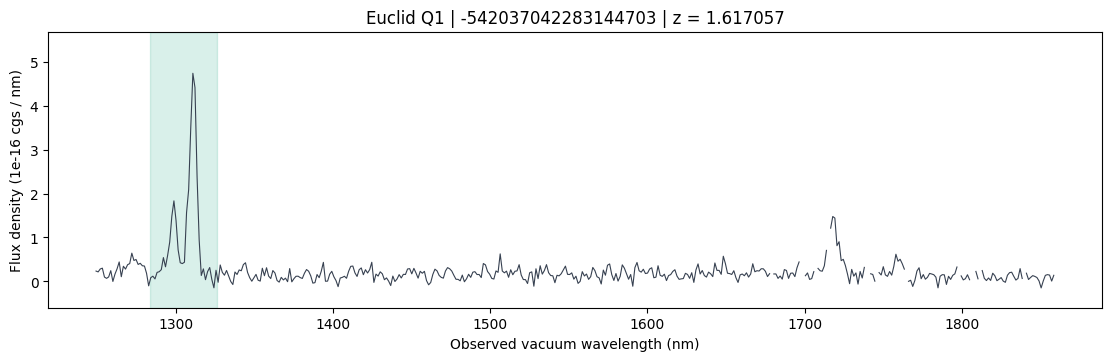

,wavelength_nm,flux_density_cgs_per_nm,sigma_cgs_per_nm,mask,ndith,quality,used
0,1283.800049,8.438749e-18,1.218732e-17,2,4,0.869648,True
1,1285.140015,1.181038e-17,1.188102e-17,0,4,0.909544,True
2,1286.479980,5.597418e-18,1.182453e-17,0,4,0.926803,True
3,1287.820068,2.045476e-17,1.185403e-17,2,4,0.923680,True
4,1289.160034,2.196715e-17,1.183187e-17,2,4,0.903043,True
5,1290.500000,2.668926e-17,1.182761e-17,2,4,0.920008,True
6,1291.840088,5.413553e-17,1.219621e-17,2,4,0.884698,True
7,1293.180054,3.317036e-17,1.181144e-17,2,4,0.897140,True
8,1294.520020,5.894479e-17,1.373102e-17,0,3,0.743025,True
9,1295.859985,8.943429e-17,1.193694e-17,0,4,0.954261,True


In [5]:
position = SkyCoord(float(source['right_ascension'])*u.deg,float(source['declination'])*u.deg)
centres = SkyCoord([269.733,61.241,52.932]*u.deg,[66.018,-48.423,-28.088]*u.deg)
field_name = ['EDF-N','EDF-S','EDF-F'][int(np.argmin(position.separation(centres)))]
display(pd.DataFrame({'quantity':source.colnames,'value':[str(source[k]) for k in source.colnames]}))
print('Field:',field_name,'| ICRS:',position.to_string('hmsdms',precision=2))
print('Spectrum ID:',spectrum['table'].meta['ID'])
print('URL:',spectrum['provenance']['url'])
print('SHA-256:',spectrum['provenance']['sha256'])
print('Spacing (nm):',spectrum['dx'])
print('Input signal / variance units:',spectrum['table']['SIGNAL'].unit,spectrum['table']['VAR'].unit)
line_query = f'''SELECT spe_line_name,spe_line_central_wl_gf,spe_line_flux_gf,
spe_line_flux_err_gf,spe_line_snr_gf,spe_line_qual_gf
FROM catalogue.spectro_line_features_catalog_spe_line_features_cat
WHERE object_id={object_id} AND spe_rank=0'''
catalogue_lines = query_table(line_query,'reference_lines').to_pandas()
display(catalogue_lines[catalogue_lines['spe_line_flux_gf']>0])
fig, ax = plt.subplots(figsize=(11,3.5),layout='constrained')
ax.plot(spectrum['x'],np.where(spectrum['good'],spectrum['y'],np.nan),color='#374151',lw=0.8)
ax.axvspan(best['expected'][0]-fit_margin_nm,best['expected'][1]+fit_margin_nm,color='#009e73',alpha=0.15)
ax.set(xlabel='Observed vacuum wavelength (nm)',ylabel='Flux density (1e-16 cgs / nm)',
       title=f'Euclid Q1 | {object_id} | z = {float(source["spe_z"]):.6f}')
ax.set_ylim(-0.6,max(float(np.max(best['y']))*1.2,float(np.percentile(spectrum['y'][spectrum['good']],99))))
if export_png:
    fig.savefig(photos/'1D_spectra.PNG',dpi=figure_dpi,facecolor='white',bbox_inches='tight',pad_inches=0.15)
plt.show()
local_all = (spectrum['x']>=best['expected'][0]-fit_margin_nm)&(spectrum['x']<=best['expected'][1]+fit_margin_nm)
pixel_table = pd.DataFrame({
    'wavelength_nm':spectrum['x'][local_all],
    'flux_density_cgs_per_nm':spectrum['y'][local_all]*FLUX_SCALE,
    'sigma_cgs_per_nm':spectrum['e'][local_all]*FLUX_SCALE,
    'mask':spectrum['mask'][local_all],'ndith':spectrum['ndith'][local_all],
    'quality':spectrum['quality'][local_all],'used':spectrum['good'][local_all]})
display(pixel_table)

## 5. Fluxes and uncertainty

    R = F5007/F4959
    variance(R) = R**2 * (C11/F4959**2 + C22/F5007**2 - 2*C12/(F4959*F5007))

The covariance includes continuum, centre and width uncertainty. A seeded
parametric Monte Carlo draws noise about the best model, with pixel sigma
multiplied by sqrt(max(1, reduced chi2)), then refits all eight parameters.
This checks nonlinearity, not unknown systematics.

SIR resampling can correlate adjacent bins, but this product supplies no full
pixel covariance matrix. Reported uncertainties are **approximate statistical
errors with a residual-scatter allowance**, not complete total errors.

In [6]:
p = best['p']
names = ['continuum_at_pivot','continuum_slope','F4959','F5007',
         'mu4959_nm','mu5007_nm','sigma4959_nm','sigma5007_nm']
display(pd.DataFrame({'parameter':names,'value':p,'sigma':np.sqrt(np.diag(best['cov']))}))
print('Flux parameters are in 1e-16 erg/s/cm^2; continuum is per nm.')
print('Pivot (nm):',best['pivot'],'| N/dof/reduced chi2:',len(best['x']),best['dof'],best['redchi'])
print('Noise inflation:',np.sqrt(max(1,best['redchi'])))
print('Flux covariance in (1e-16 cgs)^2:',best['flux_cov'])
rng = np.random.default_rng(random_seed)
mc_params, mc_failed, mc_boundary = [], 0, 0
effective_error = best['e']*np.sqrt(max(1,best['redchi']))
for draw in range(monte_carlo_draws):
    simulated = best['model']+rng.normal(0,effective_error)
    trial = least_squares(lambda pp:(doublet_model(pp,best['x'],best['dx'],best['pivot'])-simulated)/effective_error,
                          p,bounds=(best['lower'],best['upper']),max_nfev=1000,x_scale='jac')
    if not trial.success:
        mc_failed += 1
        continue
    mc_boundary += int(np.any(trial.active_mask))
    mc_params.append(trial.x)
mc_params = np.asarray(mc_params)
if mc_failed>0.05*monte_carlo_draws or np.mean(mc_params[:,2]<=0)>0.01:
    raise RuntimeError('Unstable Monte Carlo: denominator/convergence needs review.')
mc_ratios = mc_params[:,3]/mc_params[:,2]
ratio_percentiles = np.percentile(mc_ratios,[16,50,84])
ratio, ratio_error = best['ratio'], best['ratio_error']
results_df = pd.DataFrame({
    'line':['[O III] 4959','[O III] 5007'],'rest_vacuum_nm':REST_NM,
    'observed_center_nm':p[4:6],'sigma_center_nm':np.sqrt(np.diag(best['cov']))[4:6],
    'flux_erg_s_cm2':best['fluxes']*FLUX_SCALE,
    'sigma_flux_erg_s_cm2':np.sqrt(np.diag(best['flux_cov']))*FLUX_SCALE,
    'profile_sigma_nm':p[6:8],'flux_snr':best['fluxes']/np.sqrt(np.diag(best['flux_cov']))})
display(results_df)
display(pd.DataFrame({'quantity':['Measured ratio','Approximate statistical sigma','MC 16%','MC median','MC 84%',
                                'Theory','Measured - theory','Difference / statistical sigma','MC failures','MC boundary fits'],
                     'value':[ratio,ratio_error,*ratio_percentiles,THEORY_RATIO,ratio-THEORY_RATIO,
                              (ratio-THEORY_RATIO)/ratio_error,mc_failed,mc_boundary]}))

,parameter,value,sigma
0,continuum_at_pivot,0.187183,0.050800
1,continuum_slope,-0.002588,0.003083
2,F4959,8.099346,0.998407
3,F5007,24.862356,1.025950
4,mu4959_nm,1298.370305,0.237054
5,mu5007_nm,1310.742398,0.083161
6,sigma4959_nm,2.051275,0.265081
7,sigma5007_nm,2.133302,0.091793


Flux parameters are in 1e-16 erg/s/cm^2; continuum is per nm.
Pivot (nm): 1304.4111386253835 | N/dof/reduced chi2: 32 24 2.8888537859737347
Noise inflation: 1.6996628447941475
Flux covariance in (1e-16 cgs)^2: [[0.99681559 0.26846818]
 [0.26846818 1.0525735 ]]


,line,rest_vacuum_nm,observed_center_nm,sigma_center_nm,flux_erg_s_cm2,sigma_flux_erg_s_cm2,profile_sigma_nm,flux_snr
0,[O III] 4959,496.0295,1298.370305,0.237054,8.099346e-16,9.984065e-17,2.051275,8.112273
1,[O III] 5007,500.8240,1310.742398,0.083161,2.486236e-15,1.025950e-16,2.133302,24.233496


,quantity,value
0,Measured ratio,3.069674
1,Approximate statistical sigma,0.366204
2,MC 16%,2.704832
3,MC median,3.032906
4,MC 84%,3.439400
5,Theory,2.980000
6,Measured - theory,0.089674
7,Difference / statistical sigma,0.244875
8,MC failures,0.000000
9,MC boundary fits,0.000000


## 6. Direct integration and robustness

Fit the continuum to sidebands only, excluding both cores. For each line:

    direct_flux = sum_core (data_i - fitted_continuum_i) * bin_width_i
    direct_covariance = diagonal(pixel_variance_sums) + V @ continuum_covariance @ V.T

V contains the summed continuum design vectors for each aperture. This includes
shared continuum uncertainty. The aperture comprises complete bins whose centres
lie within the specified half-width. No Gaussian wing correction is applied.
Missing core bins stop this check; they are never filled with a model.
This uses the same observations and is not an independent data set.
All sensitivity tests are reported, not chosen for agreement with 2.98.

In [7]:
xx, yy, ee = best['x'],best['y'],best['e']
centers = p[4:6]
side = (abs(xx-centers[0])>continuum_exclusion_nm)&(abs(xx-centers[1])>continuum_exclusion_nm)
assert side.sum()>=6, 'Not enough continuum sidebands.'
design = np.column_stack([np.ones(len(xx)),xx-best['pivot']])
weighted = design[side]/ee[side,None]
continuum_cov = np.linalg.inv(weighted.T@weighted)
continuum = continuum_cov@(weighted.T@(yy[side]/ee[side]))
continuum_residuals = (yy[side]-design[side]@continuum)/ee[side]
di_scale2 = max(1,float(np.sum(continuum_residuals**2)/(side.sum()-2)))
continuum_cov *= di_scale2
di_flux, vectors, pixel_var, bounds = [],[],[],[]
for center in centers:
    full_core = abs(spectrum['x']-center)<=integration_half_width_nm
    assert spectrum['good'][full_core].all(), 'Invalid direct-integration core bins.'
    core = abs(xx-center)<=integration_half_width_nm
    di_flux.append(float(np.sum((yy-design@continuum)[core])*best['dx']))
    vectors.append(np.sum(design[core],axis=0)*best['dx'])
    pixel_var.append(float(np.sum(ee[core]**2)*best['dx']**2*di_scale2))
    bounds.append((float(xx[core].min()-best['dx']/2),float(xx[core].max()+best['dx']/2)))
di_flux, vectors = np.asarray(di_flux),np.asarray(vectors)
di_cov = np.diag(pixel_var)+vectors@continuum_cov@vectors.T
di_ratio = float(di_flux[1]/di_flux[0])
gradient = np.array([-di_ratio/di_flux[0],1/di_flux[0]])
di_ratio_error = float(np.sqrt(gradient@di_cov@gradient))
display(pd.DataFrame({'line':results_df['line'],'aperture_nm':bounds,'direct_flux_cgs':di_flux*FLUX_SCALE,
                      'sigma_direct_flux_cgs':np.sqrt(np.diag(di_cov))*FLUX_SCALE}))
print('Sideband continuum intercept/slope:',continuum,'| covariance:',continuum_cov)
print(f'Direct-integration ratio: {di_ratio:.3f} +/- {di_ratio_error:.3f}')
checks = [dict(test='Baseline: free widths, linear continuum',ratio=ratio,sigma=ratio_error,reduced_chi2=best['redchi'])]
for label,kwargs in [
    ('Constant continuum',dict(continuum_order=0)),
    ('Shared width; free fluxes',dict(shared_width=True)),
    ('Narrower sidebands',dict(margin=fit_margin_nm-3)),
    ('Wider sidebands',dict(margin=fit_margin_nm+3)),
    ('Only MASK == 0',dict(strict_mask=True))]:
    try:
        check = fit_doublet(spectrum,float(source['spe_z']),**kwargs)
        checks.append(dict(test=label,ratio=check['ratio'],sigma=check['ratio_error'],
                           reduced_chi2=check['redchi'],bound_hit=check['near_bounds']))
    except (ValueError,RuntimeError,np.linalg.LinAlgError) as exc:
        checks.append(dict(test=label,error=str(exc)))
checks.append(dict(test='Sideband-subtracted direct integration',ratio=di_ratio,sigma=di_ratio_error))
sensitivity_df = pd.DataFrame(checks)
display(sensitivity_df)
model_range = sensitivity_df.iloc[:-1]['ratio'].agg(['min','max'])
print('Model/window/mask sensitivity range:',model_range.to_dict())
print('This range is a diagnostic, not another independent sigma.')
if 'error' in sensitivity_df and sensitivity_df['error'].notna().any():
    display(Markdown('**Incomplete robustness check:** at least one alternative fit could not be '
        'performed; see its error in the table. In particular, failure of the MASK=0 test means '
        'we cannot validate this result using only completely unflagged bins. The baseline '
        'retains LOW_SNR/partial-pixel flags under the documented basic mask policy.'))

,line,aperture_nm,direct_flux_cgs,sigma_direct_flux_cgs
0,[O III] 4959,"(1293.8500366210938, 1301.8900756835938)",7.437867e-16,6.662376e-17
1,[O III] 5007,"(1307.2500610351562, 1315.2899780273438)",2.258943e-15,6.597232e-17


Sideband continuum intercept/slope: [ 0.21346921 -0.00183574] | covariance: [[ 1.50616945e-03 -5.17139468e-06]
 [-5.17139468e-06  6.30827810e-06]]
Direct-integration ratio: 3.037 +/- 0.271


,test,ratio,sigma,reduced_chi2,bound_hit
0,"Baseline: free widths, linear continuum",3.069674,0.366204,2.888854,NaN
1,Constant continuum,2.957934,0.329605,2.853537,False
2,Shared width; free fluxes,3.001059,0.272778,2.780034,False
3,Narrower sidebands,3.244252,0.421255,2.959262,False
4,Wider sidebands,2.940063,0.337888,2.925705,False
5,Only MASK == 0,2.704410,0.420601,2.203577,False
6,Sideband-subtracted direct integration,3.037085,0.270565,NaN,NaN


Model/window/mask sensitivity range: {'min': 2.7044097371484135, 'max': 3.2442519842202873}
This range is a diagnostic, not another independent sigma.


## 7. Was a ratio imposed?

**No SPE amplitude or line ratio enters this measurement.** We use the observed
SIR `SIGNAL` product. SIR extraction/calibration/decontamination precedes SPE
template fitting; the downloaded signal is not reconstructed from an SPE template.
SIR models neighbouring continua and strong contaminating lines, so extraction
systematics are still possible. This is not an independent detector calibration.

Our model has two free flux parameters. Changing one does not force the other
to change. The noiseless synthetic tests below recover deliberately different
ratios of 1.5 and 5.0. They test our software, not the Universe, and are not
plotted as observational data. No requirement to agree with 2.98 appears in
selection, initial flux estimates, bounds or the likelihood.

See [SIR sections 2.2-2.3](https://arxiv.org/html/2503.15307v1) and
[SPE sections 2 and 5](https://arxiv.org/html/2503.15308v2).

In [8]:
recovery = []
for injected_ratio in [1.5,5.0]:
    injected = p.copy()
    injected[3] = injected_ratio*injected[2]
    noiseless = doublet_model(injected,xx,best['dx'],best['pivot'])
    trial = fit_doublet(spectrum,float(source['spe_z']),supplied_y=noiseless)
    np.testing.assert_allclose(trial['ratio'],injected_ratio,rtol=1e-5)
    recovery.append({'injected_ratio':injected_ratio,'recovered_ratio':trial['ratio']})
display(pd.DataFrame(recovery))
print('PASS: our fitter recovers ratios other than 2.98.')

,injected_ratio,recovered_ratio
0,1.5,1.5
1,5.0,5.0


PASS: our fitter recovers ratios other than 2.98.


## 8. A real VIS image cutout

Retrieve only a small region from Q1 `euclid_DpdMerBksMosaic` using IRSA's IBE
cutout service. Verify that the FITS WCS puts the selected coordinates at its
centre. The image is for presentation only. A contrast stretch does not alter
the spectral measurements. If retrieval fails, report it and retain the spectrum
figure without an image.

In [9]:
image_hdu, image_provenance, image_error = None,None,None
if retrieve_image:
    try:
        sia_path = cache/f'sia_{object_id}.ecsv'
        if sia_path.exists():
            image_products = Table.read(sia_path)
        else:
            result = Irsa.query_sia(pos=(position,1*u.arcsec),collection='euclid_DpdMerBksMosaic')
            image_products = result.to_table() if hasattr(result,'to_table') else result
            image_products.write(sia_path,format='ascii.ecsv',overwrite=True)
        vis = image_products[(image_products['energy_bandpassname']=='VIS')&(image_products['dataproduct_subtype']=='science')]
        if not len(vis):
            raise RuntimeError('No VIS science mosaic at this position.')
        image_path = cache/f'vis_{object_id}_{cutout_size_arcsec:g}arcsec.fits'
        prov_path = image_path.with_suffix('.provenance.json')
        if not image_path.exists():
            response = requests.get(str(vis['access_url'][0]),params={
                'center':f'{position.ra.deg},{position.dec.deg}deg',
                'size':f'{cutout_size_arcsec:g}arcsec','gzip':'false'},timeout=(20,120),stream=True)
            response.raise_for_status()
            content = bytearray()
            for block in response.iter_content(65536):
                content.extend(block)
                if len(content)>10_000_000:
                    response.close()
                    raise RuntimeError('Oversized response, not a small cutout.')
            image_path.write_bytes(content)
            prov_path.write_text(json.dumps({'url':response.url,'sha256':sha256(image_path),
                'utc':datetime.now(timezone.utc).isoformat()},indent=2))
        image_provenance = json.loads(prov_path.read_text())
        assert sha256(image_path)==image_provenance['sha256'], 'Image checksum mismatch.'
        with fits.open(image_path) as hdul:
            image_hdu = hdul[0].copy()
        image_wcs = WCS(image_hdu.header)
        target_pixel = np.array(image_wcs.world_to_pixel(position))
        center_pixel = (np.array(image_hdu.data.shape)[::-1]-1)/2
        assert np.linalg.norm(target_pixel-center_pixel)<1.5, 'Image not centred on requested galaxy.'
        print('VIS URL:',image_provenance['url'])
        print('Target/centre pixel:',target_pixel,center_pixel)
    except Exception as exc:
        image_error = f'{type(exc).__name__}: {exc}'
        image_hdu = None
        print('Image unavailable:',image_error)

VIS URL: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102043551/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102043551-59C59B_20241021T045702.713179Z_00.00.fits?center=54.20370421600613%2C-28.31447034549516deg&size=12arcsec&gzip=false
Target/centre pixel: [60.06177742 59.74695665] [60. 60.]


## 9. Publication figures and compact results

Black points: unsmoothed SIR data. Coloured components: independently fitted,
bin-averaged oxygen lines. Black curve: their sum plus continuum. Bottom panel:
residuals divided by the supplied pixel sigma. Labels use traditional line names;
the wavelength axis and measured centres are in nm.

The predicted **energy-flux** ratio is 2.98, not the photon transition-probability
ratio of approximately 3.01. [Storey & Zeippen (2000)](https://doi.org/10.1046/j.1365-8711.2000.03184.x)

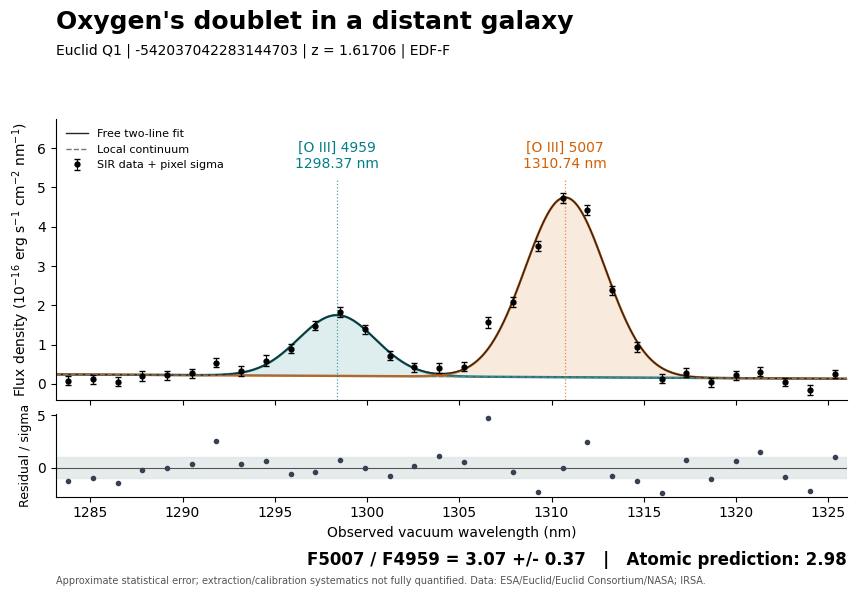

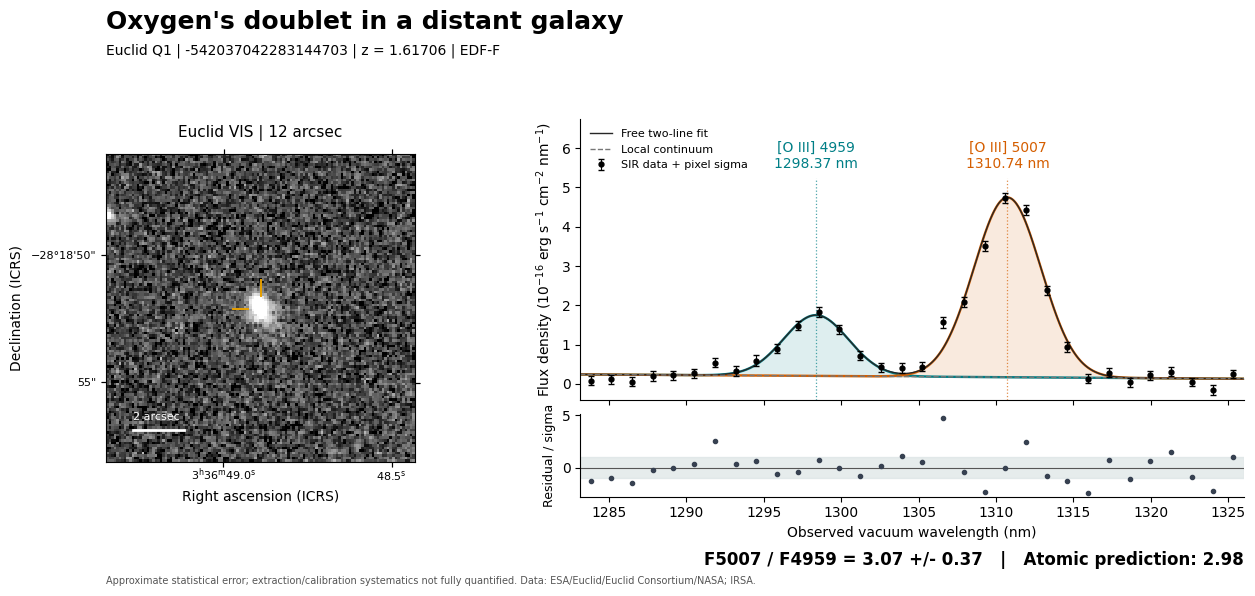

### Plain-language result
For object **-542037042283144703**, the stronger oxygen line carries **3.07 +/- 0.37 times** the energy flux of the weaker line. The approximate one-sigma statistical error includes residual-scatter inflation. This is **consistent with 2.98** (difference 0.24 statistical sigma). The Monte Carlo central 68% interval is **2.70 to 3.44**. Direct integration gives **3.04 +/- 0.27**.

The two fluxes were independently fitted to SIR pixels, with no imposed atomic ratio. This is a local check of the extracted spectrum and familiar atomic physics, not evidence of cosmological fine-tuning, changing fundamental constants, or universal Q1 accuracy. Extraction, contamination and calibration uncertainties are not fully quantified.

In [10]:
def publication_plot(with_image=True):
    include_image = with_image and image_hdu is not None
    with plt.rc_context({'font.family':'DejaVu Sans','font.size':10,
                         'axes.spines.top':False,'axes.spines.right':False}):
        figure = plt.figure(figsize=(13,5.9) if include_image else (9.2,5.9),facecolor='white')
        left = 0.105 if include_image else 0.12
        if include_image:
            grid = figure.add_gridspec(2,2,width_ratios=[1,2.15],height_ratios=[3.4,1],
                                      left=left,right=0.98,bottom=0.16,top=0.80,wspace=0.34,hspace=0.08)
            iax = figure.add_subplot(grid[:,0],projection=image_wcs)
            data = np.asarray(image_hdu.data,float)
            border = np.concatenate([data[:12,:].ravel(),data[-12:,:].ravel(),data[:,:12].ravel(),data[:,-12:].ravel()])
            background = float(np.nanmedian(border))
            noise = float(1.4826*np.nanmedian(abs(border-background)))
            norm = ImageNormalize(vmin=background-1.5*noise,vmax=float(np.nanpercentile(data,99.7)),stretch=AsinhStretch(0.15))
            iax.imshow(data,origin='lower',cmap='gray',norm=norm,interpolation='nearest')
            cx,cy = target_pixel
            iax.plot([cx-11,cx-5],[cy,cy],color='#e69f00',lw=1.4)
            iax.plot([cx,cx],[cy+5,cy+11],color='#e69f00',lw=1.4)
            iax.coords[0].set_axislabel('Right ascension (ICRS)')
            iax.coords[1].set_axislabel('Declination (ICRS)')
            for coordinate in iax.coords:
                coordinate.set_ticks(number=3)
                coordinate.set_ticklabel(size=8,exclude_overlapping=True)
            iax.set_title(f'Euclid VIS | {cutout_size_arcsec:g} arcsec',fontsize=11,pad=12)
            pixel_scale = np.sqrt(abs(np.linalg.det(image_wcs.pixel_scale_matrix)))*3600
            iax.plot([10,10+2/pixel_scale],[12,12],color='white',lw=2)
            iax.text(10,16,'2 arcsec',color='white',fontsize=8)
            sax = figure.add_subplot(grid[0,1]); rax = figure.add_subplot(grid[1,1],sharex=sax)
        else:
            grid = figure.add_gridspec(2,1,height_ratios=[3.4,1],left=left,right=0.98,bottom=0.16,top=0.80,hspace=0.08)
            sax = figure.add_subplot(grid[0]); rax = figure.add_subplot(grid[1],sharex=sax)
        dense = np.linspace(best['x'].min()-best['dx']/2,best['x'].max()+best['dx']/2,1400)
        background = p[0]+p[1]*(dense-best['pivot'])
        smooth = background.copy()
        colors = ['#007f86','#d55e00']
        for i,color in enumerate(colors):
            component = p[2+i]*line_profile(dense,best['dx'],p[4+i],p[6+i])
            smooth += component
            sax.plot(dense,background+component,color=color,lw=1.7)
            sax.fill_between(dense,background,background+component,color=color,alpha=0.13)
        sax.plot(dense,smooth,color='#272727',lw=1,label='Free two-line fit')
        sax.plot(dense,background,color='#777777',ls='--',lw=1,label='Local continuum')
        sax.errorbar(best['x'],best['y'],best['e'],fmt='o',color='black',ms=3.5,
                     elinewidth=0.8,capsize=2,label='SIR data + pixel sigma',zorder=4)
        peak = max(float(np.max(best['y'])),float(np.max(smooth)))
        for i,label in enumerate(['[O III] 4959','[O III] 5007']):
            sax.axvline(p[4+i],ymax=0.79,color=colors[i],ls=':',lw=0.9,alpha=0.7)
            sax.text(p[4+i],peak*1.14,f'{label}\n{p[4+i]:.2f} nm',ha='center',va='bottom',color=colors[i],fontsize=10)
        sax.set_ylim(min(-0.4,float(np.min(best['y']-best['e']))*1.1),peak*1.42)
        sax.set_ylabel('Flux density ($10^{-16}$ erg s$^{-1}$ cm$^{-2}$ nm$^{-1}$)')
        sax.legend(loc='upper left',frameon=False,fontsize=8)
        sax.tick_params(labelbottom=False)
        rax.axhline(0,color='#555555',lw=0.8)
        rax.axhspan(-1,1,color='#d9e2e3',alpha=0.65)
        rax.plot(best['x'],(best['y']-best['model'])/best['e'],'o',color='#374151',ms=3)
        rax.set(ylabel='Residual / sigma',xlabel='Observed vacuum wavelength (nm)',xlim=(dense.min(),dense.max()))
        rax.yaxis.label.set_size(9)
        figure.suptitle("Oxygen's doublet in a distant galaxy",x=left,ha='left',y=0.985,fontsize=18,fontweight='bold')
        figure.text(left,0.91,f'Euclid Q1 | {object_id} | z = {float(source["spe_z"]):.5f} | {field_name}',fontsize=10)
        figure.text(0.98,0.045,f'F5007 / F4959 = {ratio:.2f} +/- {ratio_error:.2f}   |   Atomic prediction: 2.98',
                    ha='right',fontsize=12,fontweight='bold')
        figure.text(left,0.012,'Approximate statistical error; extraction/calibration systematics not fully quantified. '
                    'Data: ESA/Euclid/Euclid Consortium/NASA; IRSA.',fontsize=7,color='#555555')
        return figure

spectrum_figure = publication_plot(False)
if export_png:
    spectrum_figure.savefig(photos/'euclid_04_oiii_spectrum.png',dpi=figure_dpi,facecolor='white',bbox_inches='tight',pad_inches=0.15)
display(spectrum_figure)
plt.close(spectrum_figure)
if image_hdu is not None:
    publication_figure = publication_plot(True)
    if export_png:
        publication_figure.savefig(photos/'euclid_04_oiii_galaxy_spectrum.png',dpi=figure_dpi,facecolor='white',bbox_inches='tight',pad_inches=0.15)
    display(publication_figure)
    plt.close(publication_figure)

if export_png:
    (publication_figure if image_hdu is not None else spectrum_figure).savefig(photos/'Oxygen_duplet_visual.PNG',dpi=figure_dpi,facecolor='white',bbox_inches='tight',pad_inches=0.15)

results_df.to_csv(cache/'line_flux_results.csv',index=False)
sensitivity_df.to_csv(cache/'sensitivity_checks.csv',index=False)
pixel_table.to_csv(cache/'oiii_pixels.csv',index=False)
audit_df.to_csv(cache/'candidate_audit.csv',index=False)
summary = dict(release='Euclid Q1',object_id=object_id,ra_deg=position.ra.deg,dec_deg=position.dec.deg,
               spe_z=float(source['spe_z']),ratio=ratio,approx_statistical_sigma=ratio_error,
               mc_percentiles_16_50_84=ratio_percentiles.tolist(),theory_ratio=THEORY_RATIO,
               direct_ratio=di_ratio,direct_ratio_sigma=di_ratio_error,
               model_sensitivity_range=model_range.to_dict(),reduced_chi2=best['redchi'],
               spectrum=spectrum['provenance'],image=image_provenance,
               random_seed=random_seed,mc_draws=monte_carlo_draws,
               utc=datetime.now(timezone.utc).isoformat(),
               limitation='Approximate statistical error, no full pixel covariance/systematic budget.')
(cache/'measurement_summary.json').write_text(json.dumps(summary,indent=2))
significance = abs(ratio-THEORY_RATIO)/ratio_error
wording = 'consistent with' if significance<2 else 'in tension with under this approximate error model'
display(Markdown(
    f'### Plain-language result\nFor object **{object_id}**, the stronger oxygen line carries '
    f'**{ratio:.2f} +/- {ratio_error:.2f} times** the energy flux of the weaker line. '
    f'The approximate one-sigma statistical error includes residual-scatter inflation. '
    f'This is **{wording} 2.98** (difference {significance:.2f} statistical sigma). '
    f'The Monte Carlo central 68% interval is **{ratio_percentiles[0]:.2f} to {ratio_percentiles[2]:.2f}**. '
    f'Direct integration gives **{di_ratio:.2f} +/- {di_ratio_error:.2f}**.\n\n'
    'The two fluxes were independently fitted to SIR pixels, with no imposed atomic ratio. '
    'This is a local check of the extracted spectrum and familiar atomic physics, not evidence '
    'of cosmological fine-tuning, changing fundamental constants, or universal Q1 accuracy. '
    'Extraction, contamination and calibration uncertainties are not fully quantified.'
))

## References and reproducibility

- [Storey & Zeippen (2000): atomic ratio](https://doi.org/10.1046/j.1365-8711.2000.03184.x).
- [Euclid SIR processing and limitations](https://arxiv.org/html/2503.15307v1).
- [SIR product data model](https://euclid.esac.esa.int/dr/q1/dpdd/sirdpd/dpcards/sir_combinedspectra.html).
- [Euclid SPE methods](https://arxiv.org/html/2503.15308v2).
- [SPE fields and quality flags](https://euclid.esac.esa.int/dr/q1/dpdd/spedpd/dpcards/spe_spepfoutputcatalog.html).
- [IRSA Q1 spectrum access and units](https://caltech-ipac.github.io/irsa-tutorials/euclid-intro-1d-spectra/).
- [IRSA image cutout API](https://irsa.ipac.caltech.edu/ibe/cutouts.html).

Keep the small cache with this notebook for an exact rerun. Source provenance files
contain URLs and SHA-256 checksums; query records contain SQL and TAP job IDs.
Without the cache the notebook downloads the public data again. Do not substitute
another release silently. Selection of strong doublets is appropriate for this
demonstration, not for estimating an unbiased population-average ratio.